In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sqlalchemy import create_engine

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav.head()

Matplotlib is building the font cache; this may take a moment.


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [2]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"]).reset_index(drop=True)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"].pct_change()
)

nav_returns = nav.dropna(subset=["daily_return"]).copy()

nav_returns[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073
10,100016,2022-01-17,514.7627,0.000776


In [3]:
daily_return_stats = nav_returns["daily_return"].describe()

print(daily_return_stats)

print("\nMissing daily returns:", nav_returns["daily_return"].isna().sum())
print("Infinite daily returns:", np.isinf(nav_returns["daily_return"]).sum())
print("Funds covered:", nav_returns["amfi_code"].nunique())
print("Total return observations:", len(nav_returns))

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

Missing daily returns: 0
Infinite daily returns: 0
Funds covered: 40
Total return observations: 45960


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

cagr_results = []

for amfi_code, group in nav.groupby("amfi_code"):
    group = group.sort_values("date")

    end_date = group["date"].max()
    end_nav = group.loc[group["date"] == end_date, "nav"].iloc[0]

    result = {"amfi_code": amfi_code}

    for years in [1, 3, 5]:
        target_date = end_date - pd.DateOffset(years=years)
        past_data = group[group["date"] <= target_date]

        if len(past_data) > 0:
            start_nav = past_data.iloc[-1]["nav"]
            actual_years = (end_date - past_data.iloc[-1]["date"]).days / 365.25

            if start_nav > 0 and actual_years > 0:
                cagr = (end_nav / start_nav) ** (1 / actual_years) - 1
                result[f"cagr_{years}yr"] = cagr
            else:
                result[f"cagr_{years}yr"] = np.nan
        else:
            result[f"cagr_{years}yr"] = np.nan

    cagr_results.append(result)

cagr_df = pd.DataFrame(cagr_results)

print(cagr_df.head())
print("\nFunds:", len(cagr_df))
print("\nMissing CAGR values:")
print(cagr_df[["cagr_1yr", "cagr_3yr", "cagr_5yr"]].isna().sum())

   amfi_code  cagr_1yr  cagr_3yr  cagr_5yr
0     100016 -0.022258  0.012924       NaN
1     100025  0.037076  0.039155       NaN
2     100033  0.532772  0.324340       NaN
3     101206  0.479638  0.289602       NaN
4     101207 -0.240003 -0.041515       NaN

Funds: 40

Missing CAGR values:
cagr_1yr     0
cagr_3yr     0
cagr_5yr    40
dtype: int64


In [5]:
RISK_FREE_RATE = 0.065

sharpe_results = []

for amfi_code, group in nav_returns.groupby("amfi_code"):
    daily_returns = group["daily_return"].dropna()

    annual_return = daily_returns.mean() * 252
    annual_volatility = daily_returns.std() * np.sqrt(252)

    if annual_volatility > 0:
        sharpe_ratio = (annual_return - RISK_FREE_RATE) / annual_volatility
    else:
        sharpe_ratio = np.nan

    sharpe_results.append({
        "amfi_code": amfi_code,
        "sharpe_ratio": sharpe_ratio
    })

sharpe_df = pd.DataFrame(sharpe_results)

print(sharpe_df.head())
print("\nFunds:", len(sharpe_df))
print("\nMissing Sharpe values:")
print(sharpe_df["sharpe_ratio"].isna().sum())

   amfi_code  sharpe_ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661

Funds: 40

Missing Sharpe values:
0


In [6]:
sortino_results = []

for amfi_code, group in nav_returns.groupby("amfi_code"):
    daily_returns = group["daily_return"].dropna()

    annual_return = daily_returns.mean() * 252

    downside_returns = daily_returns[daily_returns < 0]

    if len(downside_returns) > 0:
        downside_deviation = downside_returns.std() * np.sqrt(252)
    else:
        downside_deviation = np.nan

    if downside_deviation > 0:
        sortino_ratio = (annual_return - RISK_FREE_RATE) / downside_deviation
    else:
        sortino_ratio = np.nan

    sortino_results.append({
        "amfi_code": amfi_code,
        "sortino_ratio": sortino_ratio
    })

sortino_df = pd.DataFrame(sortino_results)

print(sortino_df.head())
print("\nFunds:", len(sortino_df))
print("\nMissing Sortino values:")
print(sortino_df["sortino_ratio"].isna().sum())

   amfi_code  sortino_ratio
0     100016      -0.351047
1     100025      -0.941821
2     100033       1.829134
3     101206       1.799563
4     101207       0.276644

Funds: 40

Missing Sortino values:
0


In [8]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [9]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [10]:
from scipy.stats import linregress

benchmark["date"] = pd.to_datetime(benchmark["date"])
benchmark["close_value"] = pd.to_numeric(benchmark["close_value"], errors="coerce")

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100 = nifty100[
    ["date", "benchmark_return"]
].dropna()

alpha_beta_results = []

for amfi_code, group in nav_returns.groupby("amfi_code"):

    fund = group[["date", "daily_return"]].copy()
    fund["date"] = pd.to_datetime(fund["date"])

    merged = pd.merge(
        fund,
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 1:

        regression = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = regression.slope
        alpha = regression.intercept * 252

    else:
        beta = np.nan
        alpha = np.nan

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha,
        "beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

print(alpha_beta_df.head())
print("\nFunds:", len(alpha_beta_df))
print("\nMissing Alpha values:", alpha_beta_df["alpha"].isna().sum())
print("Missing Beta values:", alpha_beta_df["beta"].isna().sum())

   amfi_code     alpha      beta
0     100016  0.037476 -0.058268
1     100025  0.042818  0.001158
2     100033  0.271954  0.005104
3     101206  0.213998  0.021086
4     101207  0.108971 -0.065289

Funds: 40

Missing Alpha values: 0
Missing Beta values: 0


In [11]:
drawdown_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    min_idx = group["drawdown"].idxmin()

    max_drawdown = group.loc[min_idx, "drawdown"]
    drawdown_date = group.loc[min_idx, "date"]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown_pct": max_drawdown * 100,
        "drawdown_date": drawdown_date
    })

drawdown_df = pd.DataFrame(drawdown_results)

print(drawdown_df.head())
print("\nFunds:", len(drawdown_df))
print("\nMissing Maximum Drawdown values:",
      drawdown_df["max_drawdown_pct"].isna().sum())

   amfi_code  max_drawdown_pct drawdown_date
0     100016        -24.734441    2022-09-15
1     100025         -4.308264    2023-07-28
2     100033        -16.217209    2022-05-12
3     101206        -11.291596    2023-07-05
4     101207        -35.446916    2026-05-11

Funds: 40

Missing Maximum Drawdown values: 0


In [12]:
scorecard = (
    cagr_df[["amfi_code", "cagr_3yr"]]
    .merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
    .merge(alpha_beta_df[["amfi_code", "alpha"]], on="amfi_code")
    .merge(drawdown_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code")
)

performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

performance.columns = performance.columns.str.strip().str.lower()

print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [13]:
print(performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [14]:
scorecard = (
    scorecard
    .merge(
        performance[["amfi_code", "scheme_name", "expense_ratio_pct"]],
        on="amfi_code",
        how="left"
    )
)

scorecard["return_rank"] = scorecard["cagr_3yr"].rank(pct=True) * 100
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(pct=True) * 100
scorecard["alpha_rank"] = scorecard["alpha"].rank(pct=True) * 100

scorecard["expense_rank_inverse"] = (
    scorecard["expense_ratio_pct"].rank(ascending=False, pct=True) * 100
)

scorecard["drawdown_rank_inverse"] = (
    scorecard["max_drawdown_pct"].rank(pct=True) * 100
)

scorecard["fund_score"] = (
    0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank_inverse"]
    + 0.10 * scorecard["drawdown_rank_inverse"]
)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)

scorecard["rank"] = scorecard.index + 1

print(
    scorecard[
        [
            "rank",
            "amfi_code",
            "scheme_name",
            "cagr_3yr",
            "sharpe_ratio",
            "alpha",
            "expense_ratio_pct",
            "max_drawdown_pct",
            "fund_score"
        ]
    ].head(10)
)

print("\nFunds:", len(scorecard))
print("\nMissing Fund Scores:", scorecard["fund_score"].isna().sum())

   rank  amfi_code                                        scheme_name  \
0     1     148567      Mirae Asset Large Cap Fund - Regular - Growth   
1     2     120505           ICICI Pru Midcap Fund - Regular - Growth   
2     3     120843             Kotak Flexicap Fund - Regular - Growth   
3     4     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
4     5     120504          ICICI Pru Bluechip Fund - Direct - Growth   
5     6     119094                Axis Midcap Fund - Regular - Growth   
6     7     119551          SBI Bluechip Fund - Regular Plan - Growth   
7     8     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
8     9     101206      ABSL Frontline Equity Fund - Regular - Growth   
9    10     119598         SBI Small Cap Fund - Regular Plan - Growth   

   cagr_3yr  sharpe_ratio     alpha  expense_ratio_pct  max_drawdown_pct  \
0  0.339920      1.448291  0.269838               1.46        -11.265729   
1  0.317692      1.180101  0.292636         

In [15]:
top5 = scorecard.head(5).copy()

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark_pivot = benchmark.pivot_table(
    index="date",
    columns="index_name",
    values="close_value",
    aggfunc="last"
)

benchmark_returns = benchmark_pivot.pct_change().dropna()

print(benchmark_pivot.columns.tolist())
print("\nBenchmark observations:", len(benchmark_pivot))

['BSE_SMALLCAP', 'CRISIL_GILT', 'CRISIL_LIQUID', 'NIFTY100', 'NIFTY50', 'NIFTY500', 'NIFTY_MIDCAP150']

Benchmark observations: 1150


In [16]:
import matplotlib.pyplot as plt

latest_date = nav["date"].max()
start_date = latest_date - pd.DateOffset(years=3)

nav_3yr = nav[
    (nav["date"] >= start_date) &
    (nav["date"] <= latest_date)
].copy()

nav_3yr["date"] = pd.to_datetime(nav_3yr["date"])

top5_codes = top5["amfi_code"].tolist()

fund_returns = (
    nav_3yr[nav_3yr["amfi_code"].isin(top5_codes)]
    .sort_values(["amfi_code", "date"])
    .copy()
)

fund_returns["daily_return"] = (
    fund_returns.groupby("amfi_code")["nav"].pct_change()
)

fund_returns = fund_returns.dropna(subset=["daily_return"])

benchmark_3yr = benchmark_returns[
    benchmark_returns.index >= start_date
].copy()

benchmark_3yr = benchmark_3yr[
    benchmark_3yr.index <= latest_date
]

tracking_results = []

for code in top5_codes:

    fund = fund_returns[
        fund_returns["amfi_code"] == code
    ][["date", "daily_return"]].rename(
        columns={"daily_return": "fund_return"}
    )

    for benchmark_name in ["NIFTY50", "NIFTY100"]:

        bench = benchmark_3yr[
            [benchmark_name]
        ].reset_index().rename(
            columns={
                "date": "date",
                benchmark_name: "benchmark_return"
            }
        )

        merged = fund.merge(
            bench,
            on="date",
            how="inner"
        )

        tracking_error = (
            (merged["fund_return"] - merged["benchmark_return"])
            .std() * np.sqrt(252)
        )

        tracking_results.append({
            "amfi_code": code,
            "benchmark": benchmark_name,
            "tracking_error": tracking_error
        })

tracking_error_df = pd.DataFrame(tracking_results)

print(tracking_error_df)
print("\nTracking Error records:", len(tracking_error_df))

   amfi_code benchmark  tracking_error
0     148567   NIFTY50        0.191868
1     148567  NIFTY100        0.187974
2     120505   NIFTY50        0.228447
3     120505  NIFTY100        0.232661
4     120843   NIFTY50        0.205067
5     120843  NIFTY100        0.206540
6     100033   NIFTY50        0.228222
7     100033  NIFTY100        0.224976
8     120504   NIFTY50        0.188211
9     120504  NIFTY100        0.187299

Tracking Error records: 10


   amfi_code                                        scheme_name   NIFTY50  \
0     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...  0.228222   
1     120504          ICICI Pru Bluechip Fund - Direct - Growth  0.188211   
2     120505           ICICI Pru Midcap Fund - Regular - Growth  0.228447   
3     120843             Kotak Flexicap Fund - Regular - Growth  0.205067   
4     148567      Mirae Asset Large Cap Fund - Regular - Growth  0.191868   

   NIFTY100  
0  0.224976  
1  0.187299  
2  0.232661  
3  0.206540  
4  0.187974  


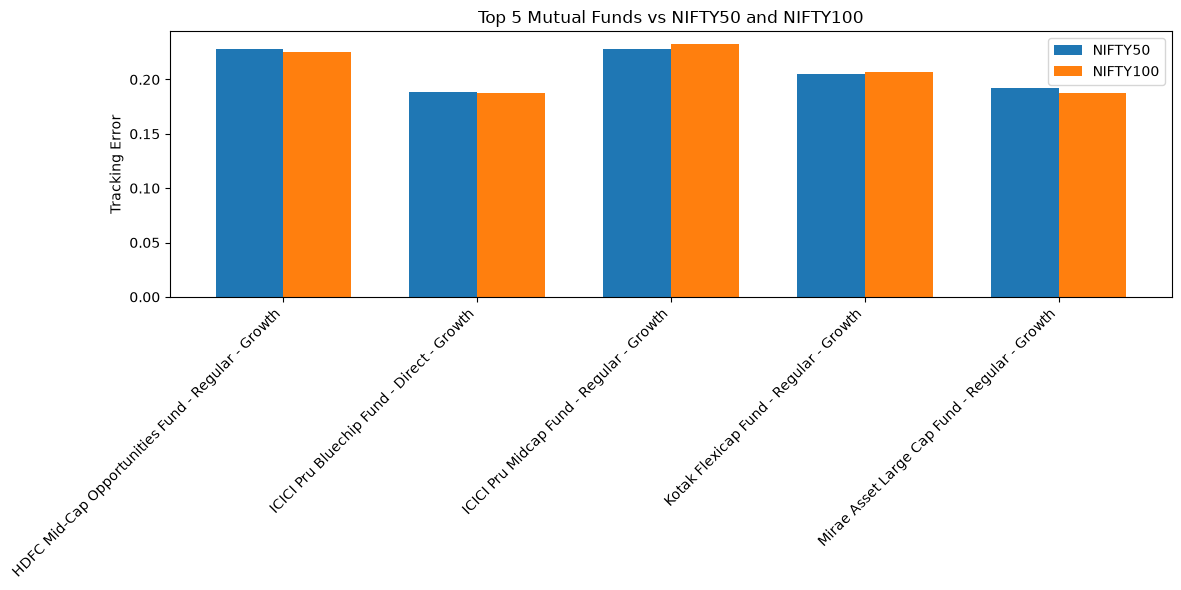

In [17]:
benchmark_comparison = tracking_error_df.pivot(
    index="amfi_code",
    columns="benchmark",
    values="tracking_error"
).reset_index()

benchmark_comparison = benchmark_comparison.merge(
    top5[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

benchmark_comparison = benchmark_comparison[
    ["amfi_code", "scheme_name", "NIFTY50", "NIFTY100"]
]

print(benchmark_comparison)

plt.figure(figsize=(12, 6))

x = np.arange(len(benchmark_comparison))
width = 0.35

plt.bar(
    x - width / 2,
    benchmark_comparison["NIFTY50"],
    width,
    label="NIFTY50"
)

plt.bar(
    x + width / 2,
    benchmark_comparison["NIFTY100"],
    width,
    label="NIFTY100"
)

plt.xticks(
    x,
    benchmark_comparison["scheme_name"],
    rotation=45,
    ha="right"
)

plt.ylabel("Tracking Error")
plt.title("Top 5 Mutual Funds vs NIFTY50 and NIFTY100")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
scorecard.to_csv("../reports/fund_scorecard.csv", index=False)

alpha_beta_df.to_csv("../reports/alpha_beta.csv", index=False)

tracking_error_df.to_csv("../reports/tracking_error.csv", index=False)

benchmark_comparison.to_csv("../reports/benchmark_comparison.csv", index=False)

print("Final exports completed successfully.")
print("fund_scorecard.csv")
print("alpha_beta.csv")
print("tracking_error.csv")
print("benchmark_comparison.csv")
print("benchmark_comparison.png")

Final exports completed successfully.
fund_scorecard.csv
alpha_beta.csv
tracking_error.csv
benchmark_comparison.csv
benchmark_comparison.png
